<a href="https://colab.research.google.com/github/princemwaanga/J-Drop/blob/main/Pre_trained_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model loaded successfully!
Loading image from: https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg
Classifying image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


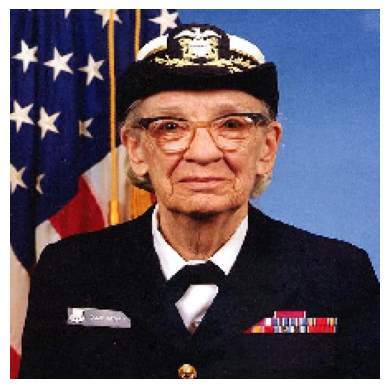

Top 5 predictions:
1: military_uniform (88.23%)
2: suit (1.33%)
3: Windsor_tie (0.61%)
4: bearskin (0.60%)
5: ballplayer (0.44%)


In [ ]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import requests
from io import BytesIO
import os

def download_pretrained_model():
    """Download and return a pre-trained MobileNetV2 model"""
    # Load MobileNetV2 pre-trained on ImageNet
    model = MobileNetV2(weights='imagenet')
    return model

def load_and_preprocess_image(img_path_or_url, from_url=False):
    """Load and preprocess an image for MobileNetV2"""
    if from_url:
        # Download image from URL
        response = requests.get(img_path_or_url)
        img = image.load_img(BytesIO(response.content), target_size=(224, 224))
    else:
        # Load image from file
        img = image.load_img(img_path_or_url, target_size=(224, 224))

    # Convert to numpy array
    img_array = image.img_to_array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Preprocess for MobileNetV2
    img_array = preprocess_input(img_array)
    return img, img_array

def classify_image(model, img_array):
    """Classify an image using the pre-trained model"""
    predictions = model.predict(img_array)
    # Decode the predictions
    decoded_predictions = decode_predictions(predictions, top=5)[0]
    return decoded_predictions

def display_results(img, predictions):
    """Display the image and classification results"""
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    print("Top 5 predictions:")
    for i, (imagenet_id, label, prob) in enumerate(predictions):
        print(f"{i+1}: {label} ({prob*100:.2f}%)")

def main():
    # Download the pre-trained model
    print("Downloading MobileNetV2 pre-trained model...")
    model = download_pretrained_model()
    print("Model loaded successfully!")

    # Example image (you can replace this with your own image path or URL)
    # Here we use a sample image URL, but you can set from_url=False and provide a local path
    image_source = "https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg"

    # Load and preprocess the image
    print(f"Loading image from: {image_source}")
    img, img_array = load_and_preprocess_image(image_source, from_url=True)

    # Classify the image
    print("Classifying image...")
    predictions = classify_image(model, img_array)

    # Display results
    display_results(img, predictions)

if __name__ == "__main__":
    main()